<a href="https://colab.research.google.com/github/simcoematthew-cpu/STAT-7220-Applied-Experimental-Design/blob/assignment-4/assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

  The objective is to determine whether there is a statistically significant difference in 100-meter sprint times between two carbon-fiber prosthetic blade designs (Aerostep and Bionic-Flex) among T64 sprinters, while accounting for the inherent performance variability across individual athletes.

2.  Specify the outcome variable and how it is measured.

  The outcome variable is 100-meter sprint time, measured in seconds. Each observation is a single timed trial for a given athlete-blade combination.

3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

  There are two independent variables. Blade Type (Aerostep vs. Bionic-Flex) is the fixed effect — these are the two specific designs the IPC wants to compare, and they exhaust the treatments of interest. Athlete (Athletes 1–5) is the random effect — these five sprinters are a sample drawn from the larger population of professional T64 sprinters, and we want to generalize beyond just these individuals.
Possible lurking variables include fatigue or learning effects across trials, environmental conditions (temperature, wind, track surface), the order in which blade types were tested, and differences in each athlete's socket/blade fit or adaptation time.

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

  A fixed effect represents a factor whose specific levels are the only ones of interest — we want to compare those exact treatments and draw conclusions about them specifically. A random effect represents a factor whose levels are sampled from a broader population — we're not interested in the specific levels themselves but rather in accounting for the variability they introduce.
We account for random effects because ignoring them would violate the independence assumption of standard ANOVA. Athletes differ systematically in speed due to biomechanics, training, and physiology. If we don't partition out that athlete-to-athlete variability, it gets lumped into the error term, which can inflate it and reduce our power to detect a true blade effect — or, depending on the design, bias our F-test entirely by using the wrong error term.

5.  State the sets of null and alternative hypotheses for this experiment.

There are two sets:
For the fixed effect (Blade Type):

H₀: μ_Aerostep = μ_Bionic-Flex (no difference in mean sprint time between blade designs)
H₁: μ_Aerostep ≠ μ_Bionic-Flex (there is a difference in mean sprint time between blade designs)

For the random effect (Athlete):

H₀: σ²_athlete = 0 (no variability in sprint times attributable to differences between athletes)
H₁: σ²_athlete > 0 (there is significant variability in sprint times due to individual athlete differences)

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

The exploratory analysis provides preliminary support for the alternative hypothesis for both effects.
For the fixed effect (Blade Type), the Aerostep blade has a lower mean sprint time (~11.26s) compared to Bionic-Flex (~11.37s), a difference of roughly 0.11 seconds. The boxplots show clear separation between the two blade types, with Aerostep's entire IQR sitting below Bionic-Flex's median.
For the random effect (Athlete), there is substantial variability between athletes. Athlete 2 is notably the fastest (mean ~11.05s) while Athlete 1 is the slowest (~11.62s), a spread of over half a second. This suggests meaningful athlete-to-athlete differences that justify including Athlete as a random effect in the model.
The interaction plot is particularly informative — every athlete is faster on the Aerostep blade, and the lines are roughly parallel. The consistent direction of the effect across all five athletes strengthens the case for a real blade type difference, while the parallel slopes suggest little to no interaction between athlete and blade type.



=== Summary by Blade Type ===
             count    mean    std    min     25%    50%     75%    max
Blade_Type                                                            
Aerostep      15.0  11.260  0.199  10.94  11.190  11.26  11.355  11.63
Bionic-Flex   15.0  11.412  0.194  11.09  11.335  11.40  11.490  11.74

=== Summary by Athlete ===
            count    mean    std    min     25%     50%     75%    max
Athlete_ID                                                            
Athlete_1     6.0  11.617  0.125  11.39  11.585  11.655  11.688  11.74
Athlete_2     6.0  11.047  0.103  10.94  10.955  11.045  11.112  11.19
Athlete_3     6.0  11.322  0.063  11.25  11.272  11.315  11.372  11.40
Athlete_4     6.0  11.390  0.100  11.24  11.352  11.385  11.432  11.54
Athlete_5     6.0  11.305  0.104  11.15  11.242  11.315  11.388  11.42

=== Cell Means (Athlete × Blade) ===
Blade_Type  Aerostep  Bionic-Flex
Athlete_ID                       
Athlete_1     11.530       11.703
Athlete_2     10.960 

/tmp/ipykernel_3598/626539262.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Blade_Type", y="Sprint_Time", data=df, ax=axes[0], palette="Set2")
/tmp/ipykernel_3598/626539262.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Athlete_ID", y="Sprint_Time", data=df, ax=axes[1], palette="Set3")


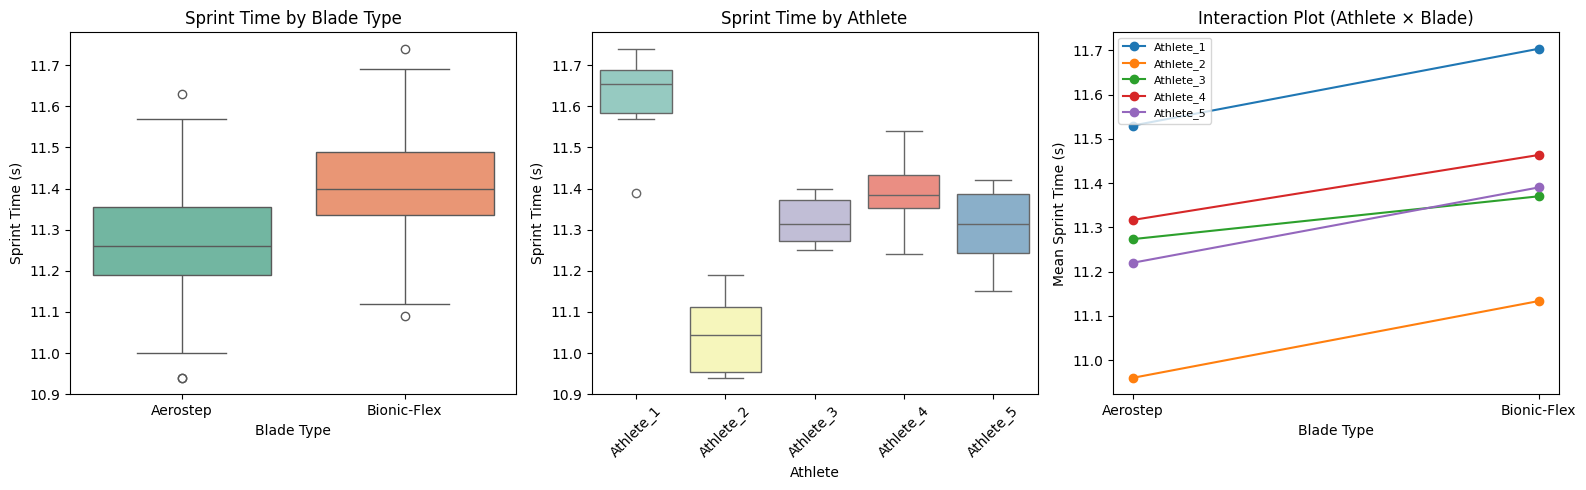

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("STAT Paralympic_Blade_Experiment.xlsx")

# Summary statistics by Blade Type
print("=== Summary by Blade Type ===")
print(df.groupby("Blade_Type")["Sprint_Time"].describe().round(3))
print()

# Summary statistics by Athlete
print("=== Summary by Athlete ===")
print(df.groupby("Athlete_ID")["Sprint_Time"].describe().round(3))
print()

# Cell means: Athlete x Blade
print("=== Cell Means (Athlete × Blade) ===")
cell_means = df.groupby(["Athlete_ID", "Blade_Type"])["Sprint_Time"].mean().unstack()
print(cell_means.round(3))

# --- Visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Boxplot by Blade Type
sns.boxplot(x="Blade_Type", y="Sprint_Time", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Sprint Time by Blade Type")
axes[0].set_ylabel("Sprint Time (s)")
axes[0].set_xlabel("Blade Type")

# 2) Boxplot by Athlete
sns.boxplot(x="Athlete_ID", y="Sprint_Time", data=df, ax=axes[1], palette="Set3")
axes[1].set_title("Sprint Time by Athlete")
axes[1].set_ylabel("Sprint Time (s)")
axes[1].set_xlabel("Athlete")
axes[1].tick_params(axis='x', rotation=45)

# 3) Interaction plot: Athlete x Blade
for athlete in df["Athlete_ID"].unique():
    sub = df[df["Athlete_ID"] == athlete].groupby("Blade_Type")["Sprint_Time"].mean()
    axes[2].plot(sub.index, sub.values, marker='o', label=athlete)
axes[2].set_title("Interaction Plot (Athlete × Blade)")
axes[2].set_ylabel("Mean Sprint Time (s)")
axes[2].set_xlabel("Blade Type")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

The assumption of normality is supported by the data from both methods.
The Shapiro-Wilk test yields W = 0.9701 with a p-value of 0.5422. Since the p-value is well above any conventional significance level (α = 0.05), we fail to reject the null hypothesis that the residuals are normally distributed.
The Q-Q plot corroborates this conclusion — the residuals follow the theoretical line closely throughout the range, with only very minor deviation at the lower tail. There are no strong S-curves, systematic bowing, or heavy-tailed patterns that would suggest a departure from normality.
Together, both the formal test and the visual method provide strong support for the normality assumption being satisfied.

                Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Sprint_Time
No. Observations:     30          Method:                 REML       
No. Groups:           5           Scale:                  0.0034     
Min. group size:      6           Log-Likelihood:         28.3941    
Max. group size:      6           Converged:              Yes        
Mean group size:      6.0                                            
---------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                 11.260    0.092 122.543 0.000 11.080 11.440
Blade_Type[T.Bionic-Flex]  0.152    0.021   7.095 0.000  0.110  0.194
Group Var                  0.041    0.542                            


Shapiro-Wilk Test: W = 0.9701, p-value = 0.5422



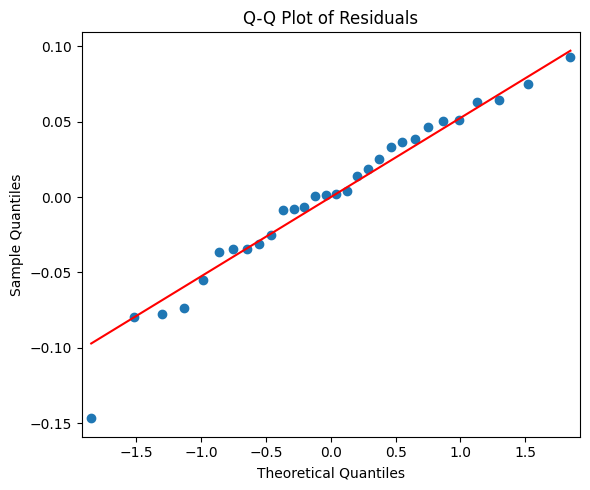

In [9]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from scipy import stats
import numpy as np

# Fit mixed effects model: Blade_Type fixed, Athlete_ID random
model = mixedlm("Sprint_Time ~ Blade_Type", data=df, groups=df["Athlete_ID"])
result = model.fit()
print(result.summary())
print()

# Extract residuals
residuals = result.resid

# --- Normality Test: Shapiro-Wilk ---
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: W = {stat:.4f}, p-value = {p:.4f}")
print()

# --- Visual: Q-Q Plot ---
fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(residuals, line='s', ax=ax)
ax.set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

 **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

 The residuals vs. fitted values plot supports the assumption of constant variance. The residuals are scattered roughly evenly above and below the zero line across the full range of fitted values, with no obvious funnel or fan shape that would indicate heteroscedasticity. The spread of residuals remains relatively consistent whether the fitted value is around 11.0 or 11.7. There is one observation near the bottom right (~11.5 fitted, ~−0.15 residual) that stands out slightly, but a single point is not sufficient to suggest a systematic pattern. Overall, the constant variance assumption appears reasonably satisfied.

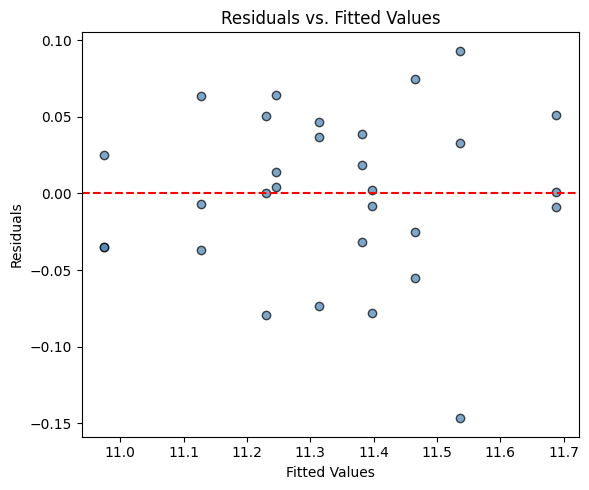

In [10]:
# Residuals vs Fitted Values plot
fitted = result.fittedvalues

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(fitted, residuals, edgecolors='black', facecolors='steelblue', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--')
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs. Fitted Values")
plt.tight_layout()
plt.show()

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

The data strongly support the alternative hypothesis that σ²_athlete > 0. The likelihood ratio test comparing the mixed model to a fixed-only OLS model yields a test statistic of 42.25 with a p-value effectively equal to zero, meaning we reject the null hypothesis that the athlete variance component is zero.
The estimated athlete variance is 0.0411 (σ = 0.2027s), which is substantially larger than the residual error variance of 0.0034. The ICC of 0.9227 tells us that approximately 92% of the total variability in sprint times (after accounting for blade type) is attributable to differences between athletes. This makes intuitive sense — individual biomechanics, training level, and muscle composition are the dominant drivers of sprint performance, far outweighing trial-to-trial noise.
This confirms that including Athlete as a random effect was the correct modeling decision. Ignoring it would have inflated the error term dramatically, potentially masking the blade type effect entirely.

In [11]:
import statsmodels.formula.api as smf

# Random effect variance from the mixed model
print("=== Random Effect (Athlete) ===")
print(f"Group Variance (σ²_athlete): {result.cov_re.iloc[0,0]:.4f}")
print(f"Group Std Dev: {np.sqrt(result.cov_re.iloc[0,0]):.4f}")
print(f"Residual Variance (σ²_error): {result.scale:.4f}")
print()

# ICC: proportion of total variance due to athlete
icc = result.cov_re.iloc[0,0] / (result.cov_re.iloc[0,0] + result.scale)
print(f"ICC (Intraclass Correlation): {icc:.4f}")
print()

# Likelihood Ratio Test: compare mixed model vs fixed-only OLS
ols_model = smf.ols("Sprint_Time ~ Blade_Type", data=df).fit()
ll_mixed = result.llf
ll_ols = ols_model.llf
LR_stat = 2 * (ll_mixed - ll_ols)
p_value = stats.chi2.sf(LR_stat, df=1) / 2  # one-sided (variance >= 0)
print(f"Log-Likelihood (Mixed): {ll_mixed:.4f}")
print(f"Log-Likelihood (OLS):   {ll_ols:.4f}")
print(f"LR Statistic: {LR_stat:.4f}")
print(f"p-value (one-sided): {p_value:.6f}")

=== Random Effect (Athlete) ===
Group Variance (σ²_athlete): 0.0411
Group Std Dev: 0.2027
Residual Variance (σ²_error): 0.0034

ICC (Intraclass Correlation): 0.9227

Log-Likelihood (Mixed): 28.3941
Log-Likelihood (OLS):   7.2671
LR Statistic: 42.2541
p-value (one-sided): 0.000000


10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

The data strongly support the alternative hypothesis that there is a significant difference in mean sprint times between the two blade designs. The Bionic-Flex blade is estimated to be 0.152 seconds slower than the Aerostep blade (z = 7.095, p ≈ 0.000). The 95% confidence interval for this difference is [0.110, 0.194], meaning we are 95% confident the true difference falls between roughly a tenth and a fifth of a second — entirely above zero, reinforcing the statistical significance.
In practical terms, the Aerostep blade yields a mean 100m sprint time of 11.260 seconds compared to 11.412 seconds for Bionic-Flex. While 0.152 seconds may seem small in everyday terms, in elite Paralympic sprinting where races are often decided by hundredths of a second, this is a meaningful performance advantage.

In [12]:
# Fixed effect (Blade Type) results
print("=== Fixed Effect (Blade Type) ===")
print(f"Intercept (Aerostep mean): {result.fe_params['Intercept']:.3f}")
print(f"Bionic-Flex effect: {result.fe_params['Blade_Type[T.Bionic-Flex]']:.3f}")
print(f"z-statistic: {result.tvalues['Blade_Type[T.Bionic-Flex]']:.4f}")
print(f"p-value: {result.pvalues['Blade_Type[T.Bionic-Flex]']:.6f}")
print(f"95% CI: [{result.conf_int().loc['Blade_Type[T.Bionic-Flex]'][0]:.3f}, {result.conf_int().loc['Blade_Type[T.Bionic-Flex]'][1]:.3f}]")

=== Fixed Effect (Blade Type) ===
Intercept (Aerostep mean): 11.260
Bionic-Flex effect: 0.152
z-statistic: 7.0947
p-value: 0.000000
95% CI: [0.110, 0.194]


The results of this experiment indicate that the Aerostep blade design produces significantly faster 100-meter sprint times than the Bionic-Flex design among T64 sprinters. On average, athletes were approximately 0.15 seconds faster using Aerostep, a margin that is both statistically significant (p ≈ 0.000) and practically meaningful in elite-level competition. This effect was consistent across all five athletes, as demonstrated by the parallel lines in the interaction plot. Additionally, the random effect analysis confirmed that individual athlete differences account for roughly 92% of the total variability in sprint times, validating the choice to use a mixed effects design rather than a standard one-way ANOVA.

However, several limitations should be noted. The sample size of five athletes is small, which limits the generalizability of these findings to the broader T64 sprinter population. The study also does not account for potential adaptation effects — athletes may perform differently with a blade they've had weeks to train on versus one used only for three trials. Fatigue and learning effects within the six total trials per athlete could also influence results, even with randomized ordering. Additionally, environmental factors such as wind, temperature, and track conditions were not controlled or reported.

Future research should expand the sample size and incorporate a longer adaptation period so athletes can fully adjust to each blade design. A crossover design with a washout period between blades would help control for carryover effects. Researchers could also consider additional performance metrics beyond raw sprint time, such as stride length, ground contact time, and energy return efficiency, to better understand the biomechanical mechanisms driving the performance difference.

*Created in collaboration with Claude AI.